In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import plot_probabilities_2d
from matplotlib import pyplot as plt



# All features (full)

## FoR-Original

,Unnamed: 0,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,...,contrast_6,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,duration,filename,label
0,0,-305.57578,98.69117,91.518230,64.501396,-8.724127,35.467377,7.637456,37.009800,-9.634664,...,27.074734,0.075360,0.048465,-0.009360,0.015261,0.010162,0.015641,2.665805,file1.wav,0
1,1,-274.76038,69.54157,120.229614,42.357440,-14.591383,27.415894,61.321335,29.847486,-11.726446,...,54.869202,0.009631,-0.016616,-0.016197,-0.000622,-0.004349,-0.005843,4.875011,file10.wav,0
2,2,-316.97860,99.30693,120.701470,62.973370,18.388845,31.745300,60.508990,35.698803,-3.781815,...,60.676906,0.020359,0.035678,-0.023923,0.022404,0.015635,0.011816,3.815102,file100.wav,0
3,3,-309.61940,105.73170,89.720440,83.421850,3.568671,46.698280,8.826833,34.290250,-21.344273,...,27.397443,-0.011907,-0.003595,0.003600,0.000963,0.012534,0.004236,9.713061,file1000.wav,0
4,4,-291.03210,71.63723,88.693660,92.446915,-8.028616,52.509770,2.189749,36.795242,-13.003433,...,27.370921,0.017905,0.005795,0.032928,0.016310,-0.002953,0.002103,4.430522,file10000.wav,0


<Axes: xlabel='label', ylabel='count'>

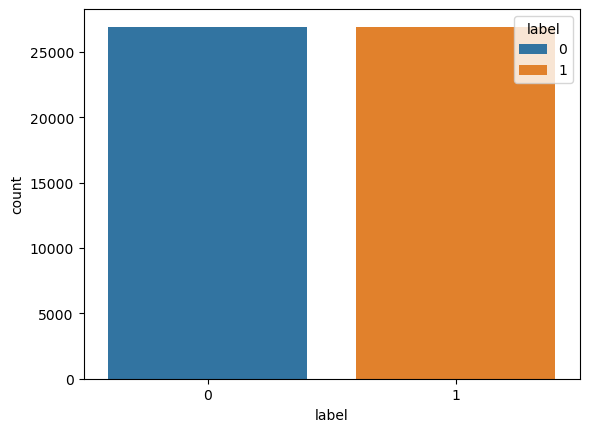

In [187]:
training_df = pd.read_csv('data/training.csv')
testing_df = pd.read_csv('data/testing.csv')
validation_df = pd.read_csv('data/validation.csv')
training_df['label'] = training_df['label'].astype('category')
testing_df['label'] = testing_df['label'].astype('category')
# validation_df['label'] = training_df['label'].astype('category')


display(training_df.head())
training_df['label'].value_counts()
sns.countplot(data=training_df, x='label', hue='label')

In [188]:
# векторы признаков
X_train = training_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_test = testing_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_valid = validation_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
# векторы ответов
y_train = training_df['label']
y_test = testing_df['label']
y_valid = validation_df['label']
X_valid.head()

,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,contrast_3,contrast_4,contrast_5,contrast_6,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5
0,-311.51804,108.219300,82.452065,54.362095,-0.866406,41.808370,21.114666,27.142424,-14.718886,23.476416,...,19.329285,19.949279,22.584370,27.199025,0.022784,0.013428,-0.015054,0.000862,0.001114,-0.000384
1,-298.88530,86.319350,97.215020,74.828125,2.661584,47.882668,3.313045,35.063866,-12.544292,23.904390,...,17.215255,20.771091,21.301038,26.928983,0.017945,-0.006906,0.027744,0.038287,0.004151,0.003610
2,-368.31213,135.093490,110.413940,38.224890,-4.557162,40.481030,44.569620,36.240547,10.459233,17.943512,...,13.942254,15.400996,16.913952,56.555454,-0.006876,0.006312,-0.006268,0.029629,0.004202,0.005358
3,-310.99747,84.175080,78.490330,74.415250,-8.453429,40.919926,26.348724,42.842438,-5.376661,17.668960,...,17.327210,20.631316,22.118647,28.462182,-0.006960,-0.008168,0.009596,-0.017637,0.011438,0.013301
4,-278.65915,91.293106,105.651610,52.242825,4.457033,32.129837,17.706459,35.052254,0.802172,26.204030,...,16.714447,19.405557,19.181224,45.228390,-0.009180,-0.017285,-0.019807,-0.041120,0.013253,-0.001772


### Random Forest

In [189]:
from sklearn import ensemble, metrics, tree
rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=5, # число деревьев
    criterion='log_loss', # критерий эффективности
    max_depth=5, # глубина дерева
    max_features='sqrt', # максимальное число признаков
    random_state=42 # генерация случайны чисел
)


# обучаем модель
rf_clf_full.fit(X_train, y_train)

y_pred_test = rf_clf_full.predict(X_test)
y_pred_valid = rf_clf_full.predict(X_valid)

print('Test metrics:\n', metrics.classification_report(y_test, y_pred_test))
print('Validation metrics:\n', metrics.classification_report(y_valid, y_pred_valid))

Test metrics:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93      2264
           1       0.96      0.90      0.93      2370

    accuracy                           0.93      4634
   macro avg       0.93      0.93      0.93      4634
weighted avg       0.94      0.93      0.93      4634

Validation metrics:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      5400
           1       0.96      0.94      0.95      5398

    accuracy                           0.95     10798
   macro avg       0.95      0.95      0.95     10798
weighted avg       0.95      0.95      0.95     10798



<Axes: >

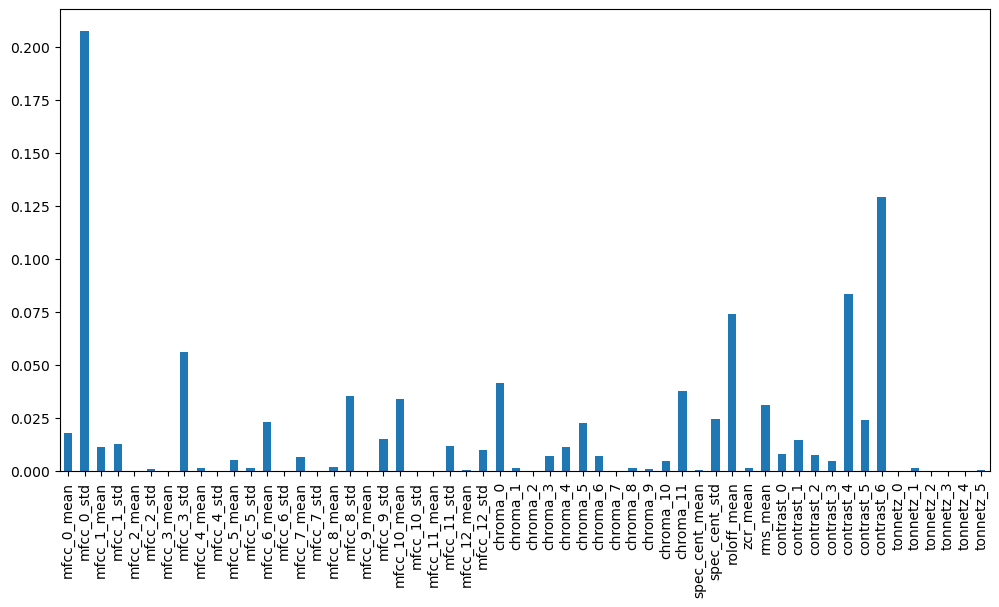

In [190]:
# Значимость признаков
feature_names = X_train.columns
importances = rf_clf_full.feature_importances_
feature_importance = pd.Series(importances, index=feature_names)
plt.figure(figsize=(12,6))
feature_importance.plot.bar()

### XGBM

In [191]:
import xgboost as xgb

xgb_train = xgb.DMatrix(X_train, y_train)
xgb_test = xgb.DMatrix(X_test, y_test)
xgb_valid = xgb.DMatrix(X_valid, y_valid)

xgb_model = xgb.train(
    params={
        'objective': 'binary:logistic',
        'max_depth': 3,
        'learning_rate': 0.1,
    },
    dtrain=xgb_train,
    num_boost_round=50
)

y_xgb_test_pred = xgb_model.predict(xgb_test) # предсказание на тестовом наборе ответов
y_xgb_test_pred = (y_xgb_test_pred > 0.75).astype(int)

y_xgb_valid_pred = xgb_model.predict(xgb_valid) # предсказание на валидационном наборе ответов
y_xgb_valid_pred = (y_xgb_valid_pred > 0.75).astype(int)


print('Testing metrics score:\n', metrics.classification_report(y_test, y_xgb_test_pred))
print('Validation metrics score:\n', metrics.classification_report(y_valid, y_xgb_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90      2264
           1       1.00      0.79      0.88      2370

    accuracy                           0.89      4634
   macro avg       0.91      0.89      0.89      4634
weighted avg       0.91      0.89      0.89      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      5400
           1       1.00      0.96      0.98      5398

    accuracy                           0.98     10798
   macro avg       0.98      0.98      0.98     10798
weighted avg       0.98      0.98      0.98     10798



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

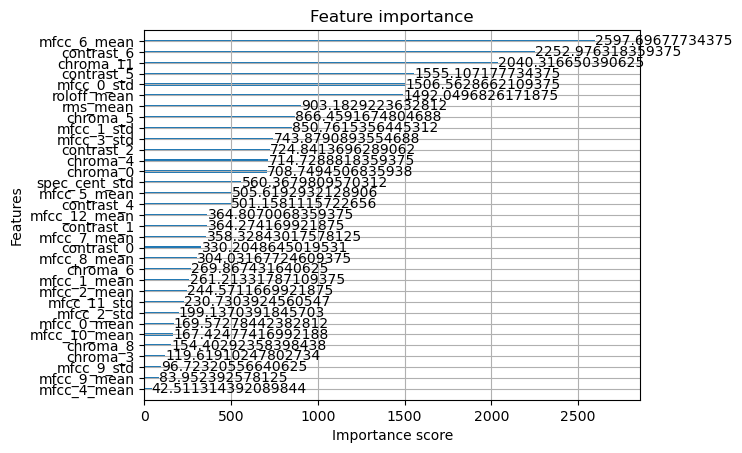

In [192]:
xgb.plot_importance(xgb_model, importance_type='gain')

### KNN

In [193]:
from sklearn import neighbors

knn_model = neighbors.KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

knn_y_test_pred = knn_model.predict(X_test)
knn_y_valid_pred = knn_model.predict(X_valid)
print('Testing metrics score:\n',metrics.classification_report(y_test, knn_y_test_pred))
print('Validation metrics score:\n',metrics.classification_report(y_valid, knn_y_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2264
           1       0.97      0.88      0.93      2370

    accuracy                           0.93      4634
   macro avg       0.93      0.93      0.93      4634
weighted avg       0.93      0.93      0.93      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      5400
           1       0.95      0.94      0.95      5398

    accuracy                           0.95     10798
   macro avg       0.95      0.95      0.95     10798
weighted avg       0.95      0.95      0.95     10798



## FoR - norm

In [194]:
norm_training_df = pd.read_csv('data/for-norm_training.csv')
norm_testing_df = pd.read_csv('data/for-norm_testing.csv')
norm_validation_df = pd.read_csv('data/for-norm_validation.csv')

X_norm_training = norm_training_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_testing = norm_testing_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_validation = norm_validation_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

y_norm_training = norm_training_df['label']
y_norm_testing = norm_testing_df['label']
y_norm_validation = norm_validation_df['label']

### Random Forest

In [195]:
norm_rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=5, # число деревьев
    criterion='log_loss', # критерий эффективности
    max_depth=5, # глубина дерева
    max_features='sqrt', # максимальное число признаков
    random_state=42 # генерация случайны чисел
)

norm_rf_clf_full.fit(X_norm_training, y_norm_training)
y_norm_pred_test = norm_rf_clf_full.predict(X_norm_testing)
y_norm_pred_valid = norm_rf_clf_full.predict(X_norm_validation)

print(metrics.classification_report(y_norm_testing, y_norm_pred_test))
print(metrics.classification_report(y_norm_validation, y_norm_pred_valid))

              precision    recall  f1-score   support

           0       0.69      0.39      0.50      2264
           1       0.59      0.84      0.69      2370

    accuracy                           0.62      4634
   macro avg       0.64      0.61      0.59      4634
weighted avg       0.64      0.62      0.60      4634

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5400
           1       0.88      0.91      0.89      5398

    accuracy                           0.89     10798
   macro avg       0.89      0.89      0.89     10798
weighted avg       0.89      0.89      0.89     10798



<Axes: >

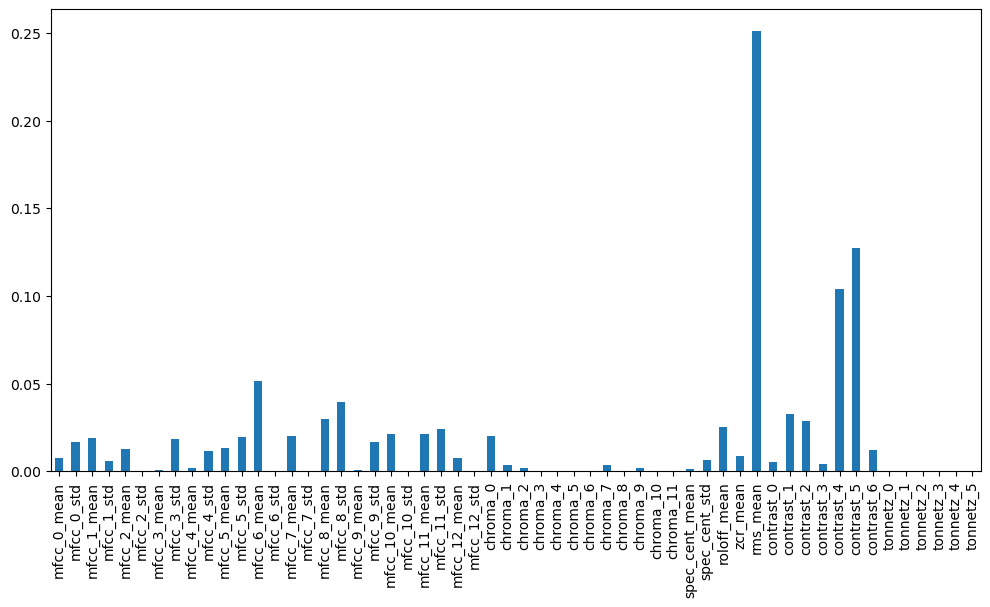

In [196]:
norm_importances = norm_rf_clf_full.feature_importances_
norm_feature_importances = pd.Series(norm_importances, index=X_norm_training.columns)
plt.figure(figsize=(12,6))
norm_feature_importances.plot.bar()

### XGBoost

In [197]:
xgb_norm_train = xgb.DMatrix(X_norm_training, y_norm_training)
xgb_norm_test = xgb.DMatrix(X_norm_testing, y_norm_testing)
xgb_norm_valid = xgb.DMatrix(X_norm_validation, y_norm_validation)

xgb_model = xgb.train(
    params={
        'objective': 'binary:logistic',
        'max_depth': 3,
        'learning_rate': 0.1,
    },
    dtrain=xgb_norm_train,
    num_boost_round=50
)

y_xgb_norm_test_pred = xgb_model.predict(xgb_norm_test) # предсказание на тестовом наборе ответов
y_xgb_norm_test_pred = (y_xgb_norm_test_pred > 0.75).astype(int)

y_xgb_norm_valid_pred = xgb_model.predict(xgb_norm_valid) # предсказание на валидационном наборе ответов
y_xgb_norm_valid_pred = (y_xgb_norm_valid_pred > 0.75).astype(int)


print('Testing metrics score:\n', metrics.classification_report(y_norm_testing, y_xgb_norm_test_pred))
print('Validation metrics score:\n', metrics.classification_report(y_norm_validation, y_xgb_norm_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.49      0.98      0.65      2264
           1       0.20      0.00      0.01      2370

    accuracy                           0.48      4634
   macro avg       0.34      0.49      0.33      4634
weighted avg       0.34      0.48      0.32      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92      5400
           1       0.99      0.83      0.90      5398

    accuracy                           0.91     10798
   macro avg       0.92      0.91      0.91     10798
weighted avg       0.92      0.91      0.91     10798



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

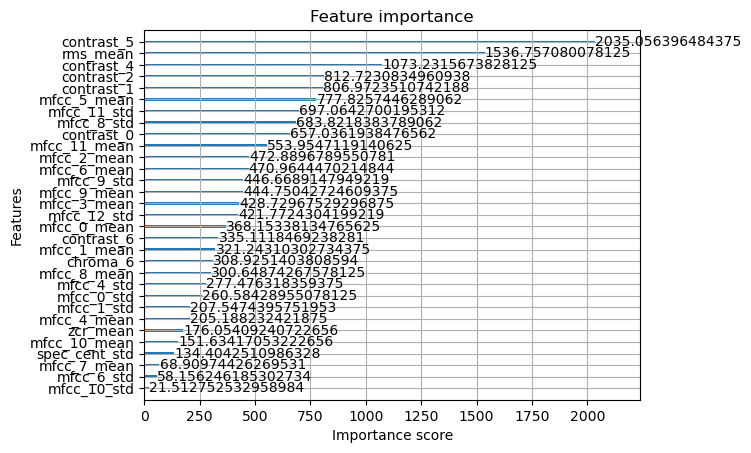

In [198]:
xgb.plot_importance(xgb_model, importance_type='gain')



### KNN

In [199]:
knn_norm_model = neighbors.KNeighborsClassifier(n_neighbors=3)
knn_norm_model.fit(X_train, y_train)

knn_norm_y_test_pred = knn_model.predict(X_norm_testing)
knn_norm_y_valid_pred = knn_model.predict(X_norm_validation)
print('Testing metrics score:\n',metrics.classification_report(y_norm_testing, knn_norm_y_test_pred))
print('Validation metrics score:\n',metrics.classification_report(y_norm_validation, knn_norm_y_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.51      0.98      0.67      2264
           1       0.82      0.10      0.17      2370

    accuracy                           0.53      4634
   macro avg       0.66      0.54      0.42      4634
weighted avg       0.67      0.53      0.41      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.56      0.92      0.69      5400
           1       0.77      0.27      0.40      5398

    accuracy                           0.60     10798
   macro avg       0.66      0.60      0.55     10798
weighted avg       0.66      0.60      0.55     10798



## FoR - 2sec

In [200]:
sec_train = pd.read_csv('data/for-2sec_training.csv')
sec_test = pd.read_csv('data/for-2sec_testing.csv')
sec_valid = pd.read_csv('data/for-2sec_validation.csv')

X_sec_train = sec_train.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_test = sec_test.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_valid = sec_valid.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

y_sec_train = sec_train['label']
y_sec_test = sec_test['label']
y_sec_valid = sec_valid['label']


### RF

In [201]:
sec_rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=30,
    criterion='entropy',
    max_depth=10,
    max_features=30,
    random_state=42
)

sec_rf_clf_full.fit(X_sec_train, y_sec_train)

y_sec_test_pred = sec_rf_clf_full.predict(X_sec_test)
y_sec_valid_pred = sec_rf_clf_full.predict(X_sec_valid)

print(metrics.classification_report(y_sec_test, y_sec_test_pred))
print(metrics.classification_report(y_sec_valid, y_sec_valid_pred))

              precision    recall  f1-score   support

           0       0.50      0.98      0.66       544
           1       0.45      0.02      0.03       544

    accuracy                           0.50      1088
   macro avg       0.47      0.50      0.35      1088
weighted avg       0.47      0.50      0.35      1088

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1413
           1       0.98      0.99      0.98      1413

    accuracy                           0.98      2826
   macro avg       0.98      0.98      0.98      2826
weighted avg       0.98      0.98      0.98      2826



<Axes: >

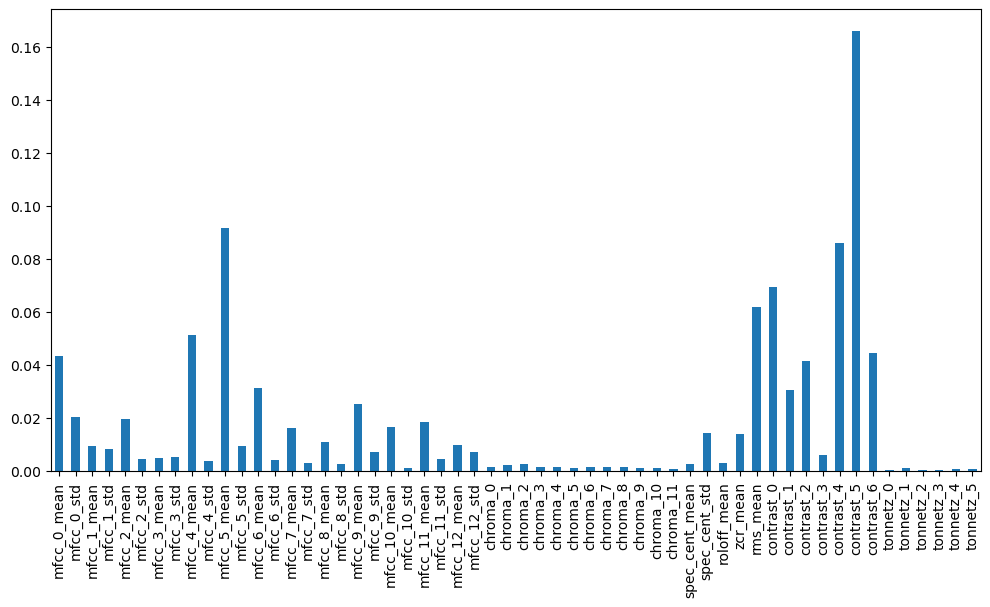

In [202]:
sec_importances = sec_rf_clf_full.feature_importances_
sec_feature_importances = pd.Series(sec_importances, index=X_sec_train.columns)
plt.figure(figsize=(12,6))
sec_feature_importances.plot.bar()

### XGB

In [203]:
xgb_sec_train = xgb.DMatrix(X_sec_train, y_sec_train)
xgb_sec_test = xgb.DMatrix(X_sec_test, y_sec_test)
xgb_sec_valid = xgb.DMatrix(X_sec_valid, y_sec_valid)

xgb_sec = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth': 5,
        'learning_rate': 0.5
    },
    dtrain=xgb_sec_train,
    num_boost_round=50
)

y_xgb_sec_test_pred = xgb_sec.predict(xgb_sec_test)
y_xgb_sec_test_pred = (y_xgb_sec_test_pred > 0.75).astype(int)
y_xgb_sec_valid_pred = xgb_sec.predict(xgb_sec_valid)
y_xgb_sec_valid_pred = (y_xgb_sec_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_sec_test, y_xgb_sec_test_pred))
print(metrics.classification_report(y_sec_valid, y_xgb_sec_valid_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       544
           1       0.00      0.00      0.00       544

    accuracy                           0.50      1088
   macro avg       0.25      0.50      0.33      1088
weighted avg       0.25      0.50      0.33      1088

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1413
           1       1.00      0.99      0.99      1413

    accuracy                           0.99      2826
   macro avg       0.99      0.99      0.99      2826
weighted avg       0.99      0.99      0.99      2826



c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

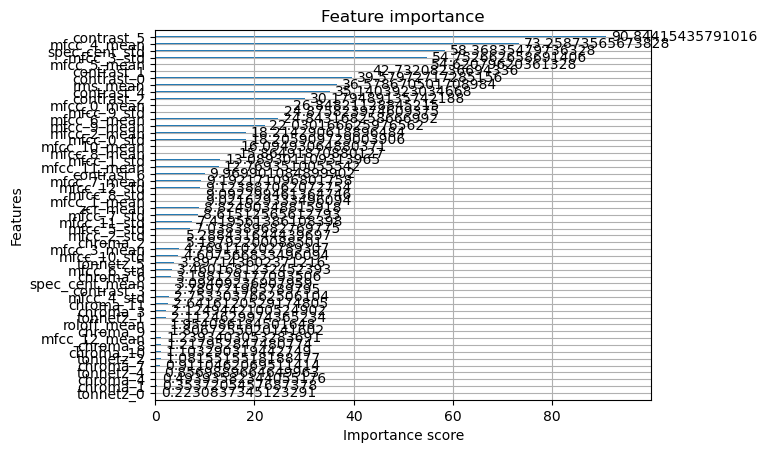

In [204]:
xgb.plot_importance(xgb_sec, importance_type='gain')

### KNN

In [205]:
knn_sec = neighbors.KNeighborsClassifier(n_neighbors=5)

knn_sec.fit(X_sec_train, y_sec_train)

y_knn_test_pred = knn_sec.predict(X_sec_test)
y_knn_valid_pred = knn_sec.predict(X_sec_valid)

print(metrics.classification_report(y_sec_test, y_knn_test_pred))
print(metrics.classification_report(y_sec_valid, y_knn_valid_pred))

              precision    recall  f1-score   support

           0       0.52      0.44      0.48       544
           1       0.52      0.60      0.56       544

    accuracy                           0.52      1088
   macro avg       0.52      0.52      0.52      1088
weighted avg       0.52      0.52      0.52      1088

              precision    recall  f1-score   support

           0       0.84      0.74      0.78      1413
           1       0.76      0.86      0.81      1413

    accuracy                           0.80      2826
   macro avg       0.80      0.80      0.80      2826
weighted avg       0.80      0.80      0.80      2826



## FoR - rerec

In [206]:
rerec_train_df = pd.read_csv('data/for-rerec_training.csv')
rerec_test_df = pd.read_csv('data/for-rerec_testing.csv')
rerec_valid_df = pd.read_csv('data/for-rerec_validation.csv')

X_rerec_train = rerec_train_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_test = rerec_test_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_valid = rerec_valid_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)

y_rerec_train = rerec_train_df['label']
y_rerec_test = rerec_test_df['label']
y_rerec_valid = rerec_valid_df['label']

### RF

In [207]:
rerec_rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_features=20,
    max_depth=10,
    random_state=42
)

rerec_rf_clf_full.fit(X_rerec_train, y_rerec_train)

y_rerec_test_pred = rerec_rf_clf_full.predict(X_rerec_test)
y_rerec_valid_pred = rerec_rf_clf_full.predict(X_rerec_valid)
print(metrics.classification_report(y_rerec_test, y_rerec_test_pred))
print(metrics.classification_report(y_rerec_valid, y_rerec_valid_pred))

              precision    recall  f1-score   support

           0       0.43      0.66      0.52       408
           1       0.28      0.13      0.18       408

    accuracy                           0.40       816
   macro avg       0.36      0.40      0.35       816
weighted avg       0.36      0.40      0.35       816

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1101
           1       0.94      0.95      0.95      1143

    accuracy                           0.94      2244
   macro avg       0.94      0.94      0.94      2244
weighted avg       0.94      0.94      0.94      2244



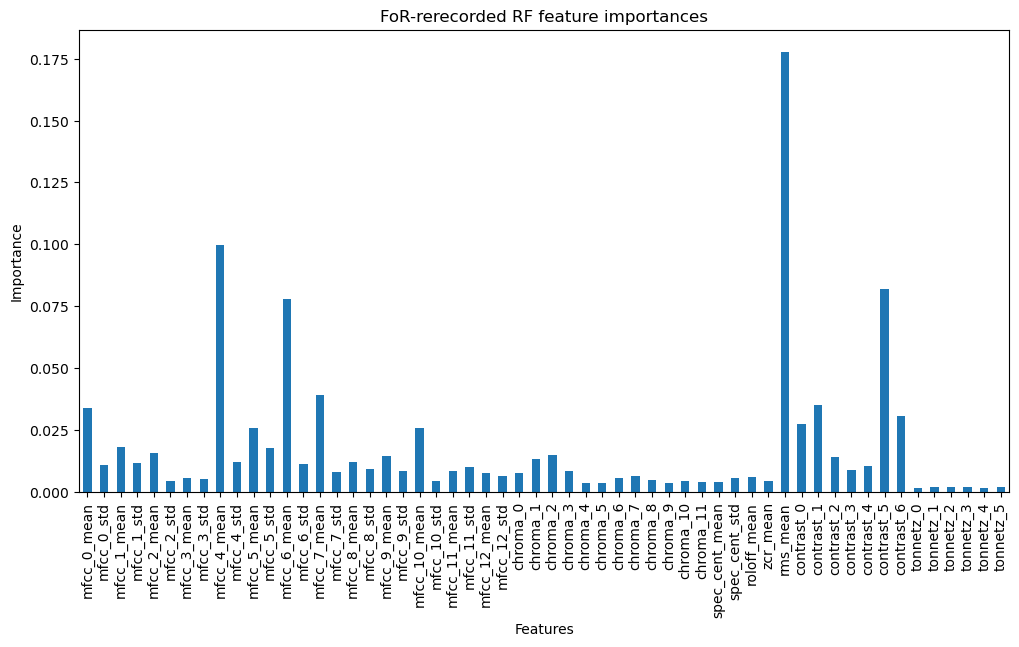

In [208]:
rerec_importances = rerec_rf_clf_full.feature_importances_
rerec_feature_importances = pd.Series(rerec_importances, index=X_rerec_train.columns)
plt.figure(figsize=(12,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('FoR-rerecorded RF feature importances')
rerec_feature_importances.plot.bar();

### XGB

In [209]:
xgb_rerec_train = xgb.DMatrix(X_rerec_train, y_rerec_train)
xgb_rerec_test = xgb.DMatrix(X_rerec_test, y_rerec_test)
xgb_rerec_valid = xgb.DMatrix(X_rerec_valid, y_rerec_valid)

xgb_rerec = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth':3,
        'learning_rate':0.1
    },
    dtrain=xgb_rerec_train,
    num_boost_round= 20
)

y_xgb_rerec_test_pred = xgb_rerec.predict(xgb_rerec_test)
y_xgb_rerec_test_pred = (y_xgb_rerec_test_pred > 0.75).astype(int)
y_xgb_rerec_valid_pred = xgb_rerec.predict(xgb_rerec_valid)
y_xgb_rerec_valid_pred = (y_xgb_rerec_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_rerec_test, y_xgb_rerec_test_pred))
print(metrics.classification_report(y_rerec_valid, y_xgb_rerec_valid_pred))


              precision    recall  f1-score   support

           0       0.48      0.91      0.62       408
           1       0.00      0.00      0.00       408

    accuracy                           0.45       816
   macro avg       0.24      0.45      0.31       816
weighted avg       0.24      0.45      0.31       816

              precision    recall  f1-score   support

           0       0.68      0.98      0.80      1101
           1       0.97      0.56      0.71      1143

    accuracy                           0.77      2244
   macro avg       0.83      0.77      0.76      2244
weighted avg       0.83      0.77      0.75      2244



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

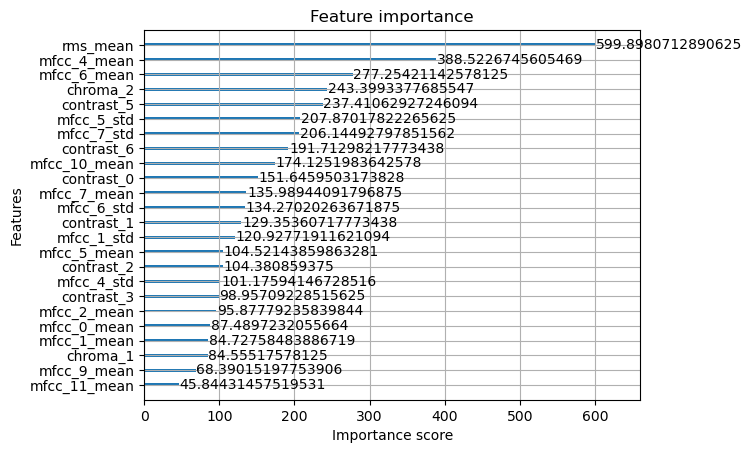

In [210]:
xgb.plot_importance(xgb_rerec, importance_type='gain')

### KNN

In [211]:
rerec_knn = neighbors.KNeighborsClassifier(n_neighbors=10)

rerec_knn.fit(X_rerec_train, y_rerec_train)

y_rerec_test_pred = rerec_knn.predict(X_rerec_test)
y_rerec_valid_pred = rerec_knn.predict(X_rerec_valid)

print(metrics.classification_report(y_rerec_test, y_rerec_test_pred))
print(metrics.classification_report(y_rerec_valid, y_rerec_valid_pred))

              precision    recall  f1-score   support

           0       0.68      0.39      0.50       408
           1       0.57      0.82      0.67       408

    accuracy                           0.60       816
   macro avg       0.63      0.60      0.59       816
weighted avg       0.63      0.60      0.59       816

              precision    recall  f1-score   support

           0       0.75      0.69      0.72      1101
           1       0.72      0.78      0.75      1143

    accuracy                           0.73      2244
   macro avg       0.74      0.73      0.73      2244
weighted avg       0.73      0.73      0.73      2244



## Summary

In [1]:
# Построить сводный график важности признаков
# Построить сводный график зависимости значений метрик от параметров

# MFCC

In [212]:
X_original_mfcc_training = training_df[training_df.columns[1:27]]
X_original_mfcc_test = testing_df[testing_df.columns[1:27]]
X_original_mfcc_valid = validation_df[validation_df.columns[1:27]]

## RF

### Original

In [213]:
rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=5,
    max_features=30,
    random_state=42
)

rf_clf_mfcc.fit(X_original_mfcc_training, y_train)

y_rf_mfcc_testing_pred = rf_clf_mfcc.predict(X_original_mfcc_test)
y_rf_mfcc_valid_pred = rf_clf_mfcc.predict(X_original_mfcc_valid)

print(metrics.classification_report(y_test, y_rf_mfcc_testing_pred))
print(metrics.classification_report(y_valid, y_rf_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.97      0.81      0.88      2264
           1       0.84      0.98      0.90      2370

    accuracy                           0.89      4634
   macro avg       0.91      0.89      0.89      4634
weighted avg       0.90      0.89      0.89      4634

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      5400
           1       0.91      0.91      0.91      5398

    accuracy                           0.91     10798
   macro avg       0.91      0.91      0.91     10798
weighted avg       0.91      0.91      0.91     10798



<Axes: >

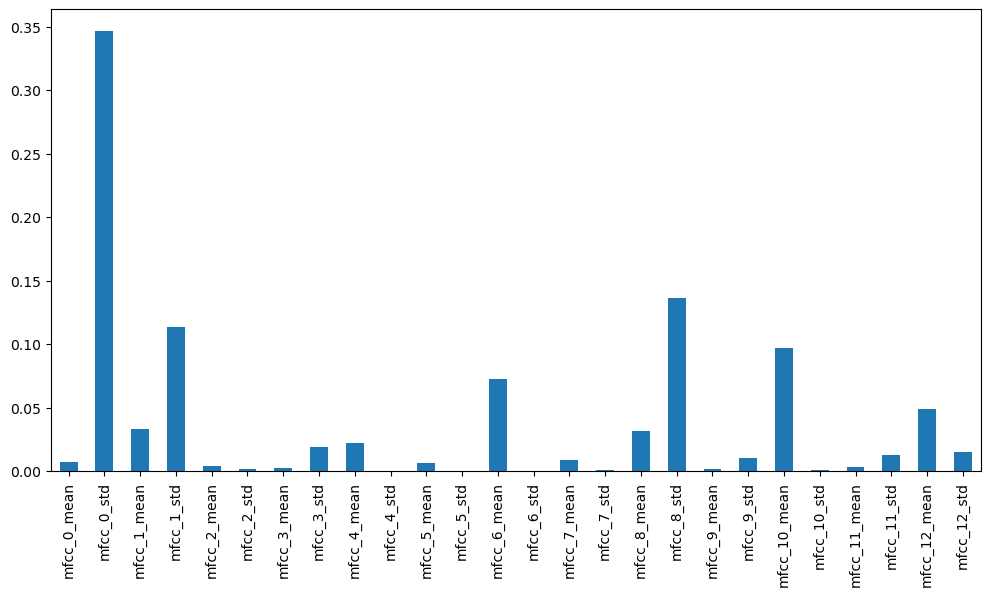

In [214]:
importances = rf_clf_mfcc.feature_importances_
orig_mfcc_feature_importances = pd.Series(importances, index=X_original_mfcc_training.columns)
plt.figure(figsize=(12,6))
orig_mfcc_feature_importances.plot.bar()

### Norm

In [215]:
X_norm_mfcc_training = norm_training_df[norm_training_df.columns[1:27]]
X_norm_mfcc_testing = norm_testing_df[norm_testing_df.columns[1:27]]
X_norm_mfcc_valid = norm_validation_df[norm_validation_df.columns[1:27]]

In [216]:
norm_rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=5,
    max_features=30,
    random_state=42
)

norm_rf_clf_mfcc.fit(X_norm_mfcc_training, y_norm_training)

norm_y_rf_mfcc_testing_pred = norm_rf_clf_mfcc.predict(X_norm_mfcc_testing)
norm_y_rf_mfcc_valid_pred = norm_rf_clf_mfcc.predict(X_norm_mfcc_valid)

print(metrics.classification_report(y_norm_testing, norm_y_rf_mfcc_testing_pred))
print(metrics.classification_report(y_norm_validation, norm_y_rf_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.81      0.72      0.76      2264
           1       0.76      0.84      0.80      2370

    accuracy                           0.78      4634
   macro avg       0.78      0.78      0.78      4634
weighted avg       0.78      0.78      0.78      4634

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      5400
           1       0.84      0.83      0.83      5398

    accuracy                           0.84     10798
   macro avg       0.84      0.84      0.84     10798
weighted avg       0.84      0.84      0.84     10798



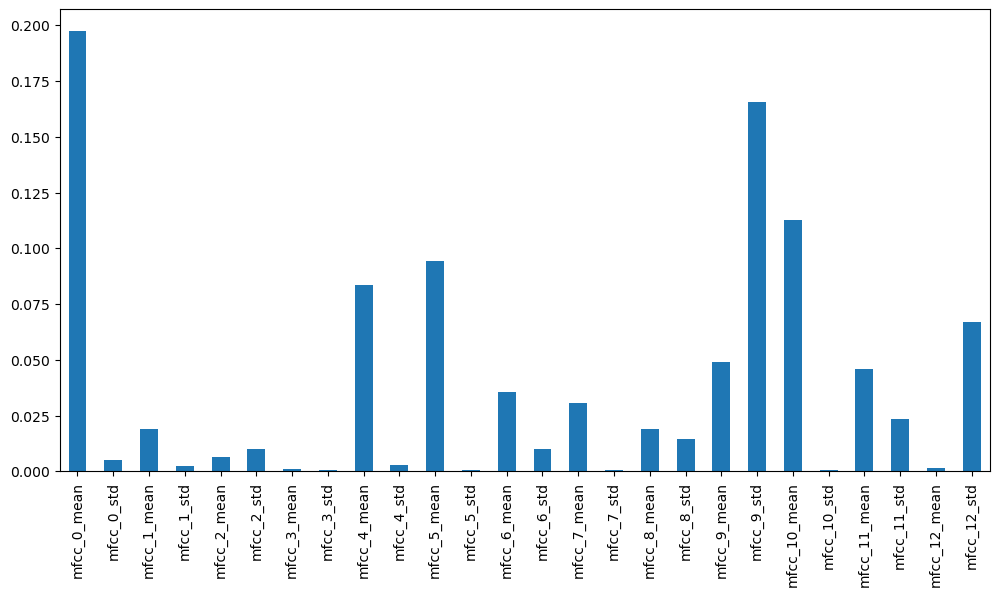

In [217]:
norm_importances = norm_rf_clf_mfcc.feature_importances_
norm_mfcc_feature_importances = pd.Series(norm_importances, X_norm_mfcc_training.columns)
plt.figure(figsize=(12,6))
norm_mfcc_feature_importances.plot.bar();

### 2sec

In [218]:
X_sec_mfcc_train = sec_train[sec_train.columns[1:27]]
X_sec_mfcc_test = sec_test[sec_test.columns[1:27]]
X_sec_mfcc_valid = sec_valid[sec_valid.columns[1:27]]

In [219]:
sec_rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=5,
    max_features=30,
    random_state=42
)

sec_rf_clf_mfcc.fit(X_sec_mfcc_train, y_sec_train)

sec_y_rf_mfcc_testing_pred = rf_clf_mfcc.predict(X_sec_mfcc_test)
sec_y_rf_mfcc_valid_pred = rf_clf_mfcc.predict(X_sec_mfcc_valid)

print(metrics.classification_report(y_sec_test, sec_y_rf_mfcc_testing_pred))
print(metrics.classification_report(y_sec_valid, sec_y_rf_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.47      0.88      0.61       544
           1       0.07      0.01      0.02       544

    accuracy                           0.44      1088
   macro avg       0.27      0.44      0.31      1088
weighted avg       0.27      0.44      0.31      1088

              precision    recall  f1-score   support

           0       0.60      0.93      0.73      1413
           1       0.84      0.39      0.53      1413

    accuracy                           0.66      2826
   macro avg       0.72      0.66      0.63      2826
weighted avg       0.72      0.66      0.63      2826



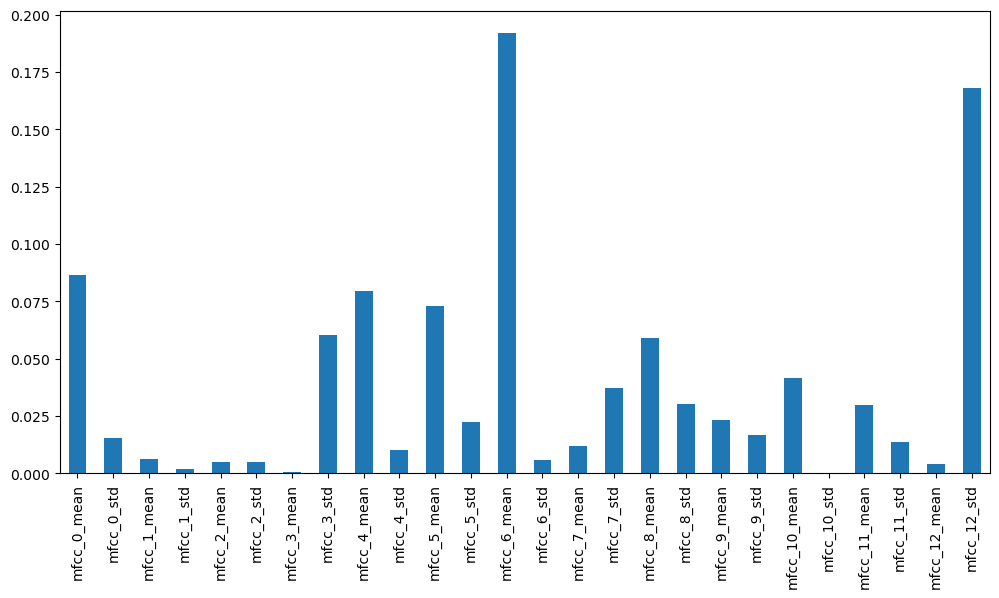

In [220]:
sec_importances = sec_rf_clf_mfcc.feature_importances_

sec_mfcc_feature_importances = pd.Series(sec_importances, X_sec_mfcc_train.columns)
plt.figure(figsize=(12,6))
sec_mfcc_feature_importances.plot.bar(); 

### rerec

In [221]:
X_rerec_mfcc_train = rerec_train_df[rerec_train_df.columns[1:27]]
X_rerec_mfcc_test = rerec_test_df[rerec_test_df.columns[1:27]]
X_rerec_mfcc_valid = rerec_valid_df[rerec_valid_df.columns[1:27]]

In [222]:
rerec_rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=25,
    criterion='entropy',
    max_depth=4,
    max_features=26,
    random_state=42
)

rerec_rf_clf_mfcc.fit(X_rerec_mfcc_train, y_rerec_train)

y_rerec_mfcc_test_pred = rerec_rf_clf_mfcc.predict(X_rerec_mfcc_test)
y_rerec_mfcc_valid_pred = rerec_rf_clf_mfcc.predict(X_rerec_mfcc_valid)

print(metrics.classification_report(y_rerec_test, y_rerec_mfcc_test_pred))
print(metrics.classification_report(y_rerec_valid, y_rerec_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.80      0.68      0.74       408
           1       0.72      0.83      0.77       408

    accuracy                           0.76       816
   macro avg       0.76      0.76      0.75       816
weighted avg       0.76      0.76      0.75       816

              precision    recall  f1-score   support

           0       0.80      0.77      0.79      1101
           1       0.79      0.82      0.80      1143

    accuracy                           0.80      2244
   macro avg       0.80      0.79      0.79      2244
weighted avg       0.80      0.80      0.79      2244



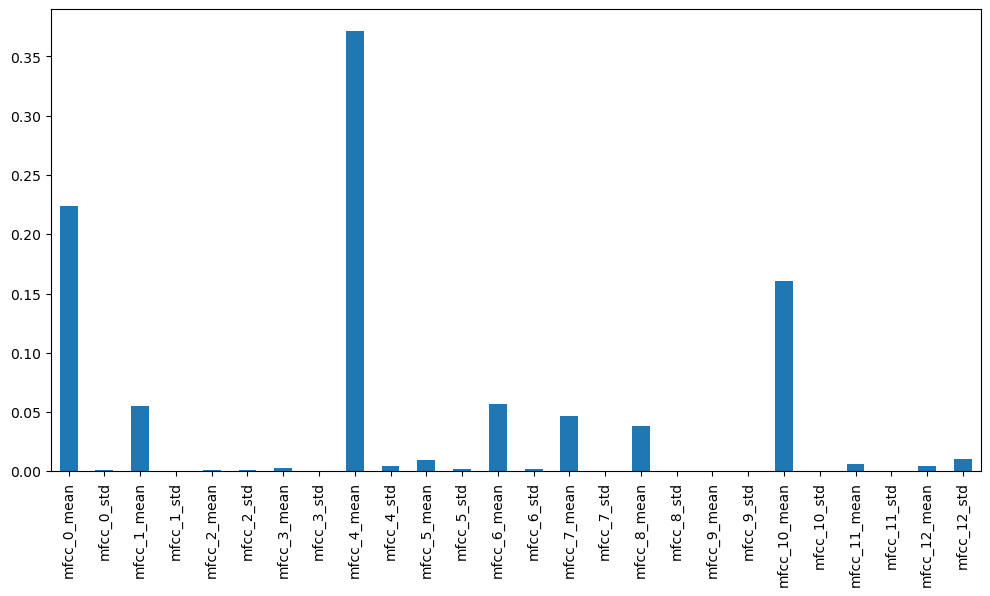

In [223]:
rerec_mfcc_importances = rerec_rf_clf_mfcc.feature_importances_
rerec_mfcc_feature_importances = pd.Series(rerec_mfcc_importances, X_rerec_mfcc_train.columns)
plt.figure(figsize=(12,6))
rerec_mfcc_feature_importances.plot.bar();

### Summary

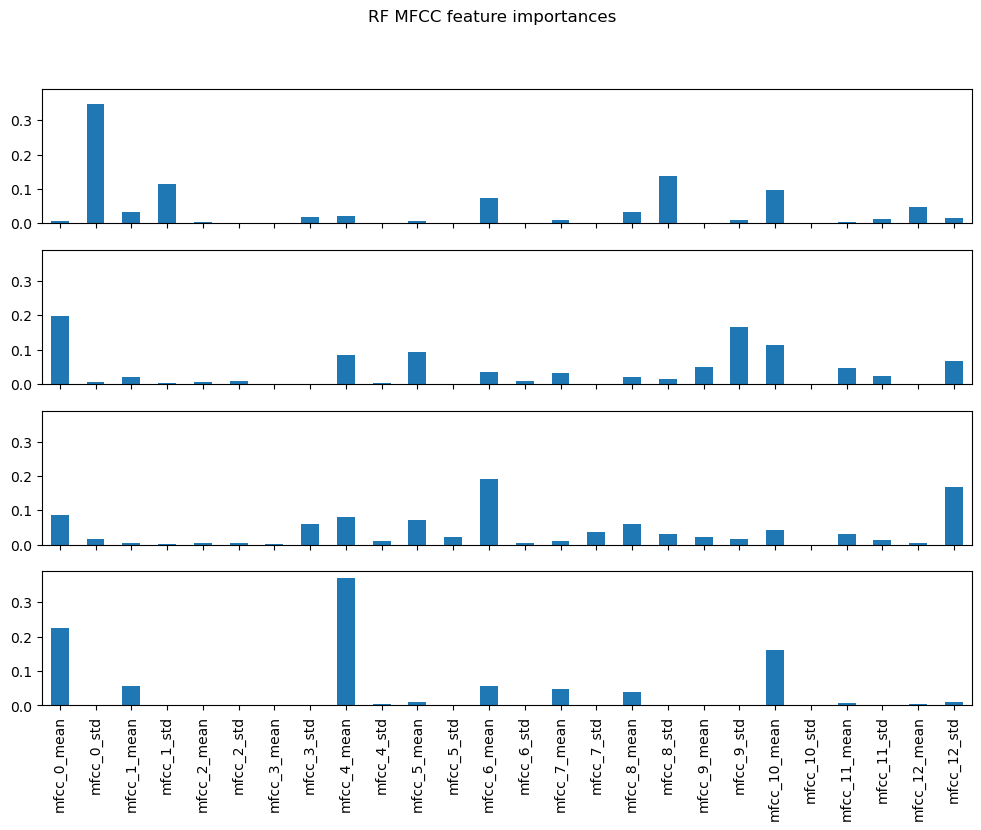

In [ ]:
fig, ax = plt.subplots(4,1, figsize=(12,8), sharex=True, sharey=True,)
orig_mfcc_feature_importances.plot.bar(ax=ax[0])
norm_mfcc_feature_importances.plot.bar(ax=ax[1])
sec_mfcc_feature_importances.plot.bar(ax=ax[2])
rerec_mfcc_feature_importances.plot.bar(ax=ax[3])
fig.suptitle('RF MFCC feature importances');

# Построить всё на одном графике (barplot)

In [2]:
# Построить сводный график зависимости значений метрик от параметров


## XGBoost

### Original

In [ ]:
# Модель на данных FoR-Original с признаками MFCC

### norm

In [ ]:
# Модель на данных FoR-norm с признаками MFCC

### 2sec

In [ ]:
# Модель на данных FoR-2sec с признаками MFCC

### rerec

In [ ]:
# Модель на данных FoR-rerec с признаками MFCC

### Summary

In [3]:
# barplot

# Построить зависимость значений метрик от параметров, сводный plot

# 

# **Contrast**

## RF

### Original

### norm

### 2sec

### rerec

### Summary

## XGBoost

### Original

### norm

### 2sec

### rerec

### Summary